

**Task 1: Hypothesis**

Dataset: https://www.kaggle.com/datasets/utkarshx27/noaa-atlantic-hurricane-database/data

**H1** : Cyclones that last longer reach higher intensity.

**H2:** Cyclones near the equator tend to be stronger.

**H3:** Lower central pressure leads to higher cyclone intensity.




In [ ]:
# Import the necessary libraries
import pandas as pd
import numpy as np

# Load the dataset (make sure 'storms.csv' is uploaded or available in your environment)
df = pd.read_csv('storms.csv')

# Show the first few rows to understand what the data looks like
print("Preview of the dataset:")
print(df.head())

# Some values use placeholders like -999 or -1998 to represent missing information.
# We'll convert these to proper NaN values so we can handle them more easily.
df['pressure'] = df['pressure'].replace(-999, np.nan)
df['tropicalstorm_force_diameter'] = df['tropicalstorm_force_diameter'].replace(-1998, np.nan)
df['hurricane_force_diameter'] = df['hurricane_force_diameter'].replace(-1998, np.nan)

# For our hypotheses, we need accurate wind, pressure, and latitude data.
# So we'll remove rows where any of these are missing.
df = df.dropna(subset=['pressure', 'wind', 'lat'])

# The data provides year, month, day, and hour in separate columns.
# We'll combine them into one datetime column to make time-based calculations easier.
df['datetime'] = pd.to_datetime(df[['year', 'month', 'day', 'hour']])

# To analyze how storms change over time, we'll sort the data by storm name and timestamp.
df = df.sort_values(by=['name', 'datetime'])

# We want each storm to be treated as a unique time series,
# so we'll clean the storm names (remove extra spaces and standardize to uppercase).
df['name'] = df['name'].str.strip().str.upper()

# In case there are any duplicate rows (same storm name and same timestamp), we’ll drop them.
duplicates = df.duplicated(subset=['name', 'datetime'])
print(f"Duplicate rows removed: {duplicates.sum()}")
df = df[~duplicates]

# Reset the index to tidy up the dataframe
df = df.reset_index(drop=True)

# Let’s create a summary dataframe where each storm is represented once.
# This is useful for testing all three hypotheses.
storm_summary = df.groupby('name').agg(
    start_time=('datetime', 'min'),
    end_time=('datetime', 'max'),
    duration_hours=('datetime', lambda x: (x.max() - x.min()).total_seconds() / 3600),
    max_wind=('wind', 'max'),
    min_pressure=('pressure', 'min'),
    avg_latitude=('lat', 'mean')
).reset_index()

# Preview the summarized dataset (one row per storm)
print("\nStorm summary for hypothesis testing:")
print(storm_summary.head())

# Check how many complete entries we have after aggregation
print("\nTotal storms available for analysis:", len(storm_summary))


Preview of the dataset:
       name  year  month  day  hour   lat  long               status  \
0  AL011975  1975      6   24    12  32.5 -52.0  tropical depression   
1  AL011975  1975      6   24    18  32.6 -52.6  tropical depression   
2  AL011975  1975      6   25     0  32.7 -53.2  tropical depression   
3  AL011975  1975      6   25    60  32.8 -53.2  tropical depression   
4  AL011975  1975      6   25    12  33.0 -54.5  tropical depression   

   category  wind  pressure  tropicalstorm_force_diameter  \
0       NaN    20      -999                         -1998   
1       NaN    25      -999                         -1998   
2       NaN    25      -999                         -1998   
3       NaN    25      -999                         -1998   
4       NaN    25      -999                         -1998   

   hurricane_force_diameter  
0                     -1998  
1                     -1998  
2                     -1998  
3                     -1998  
4                     -199

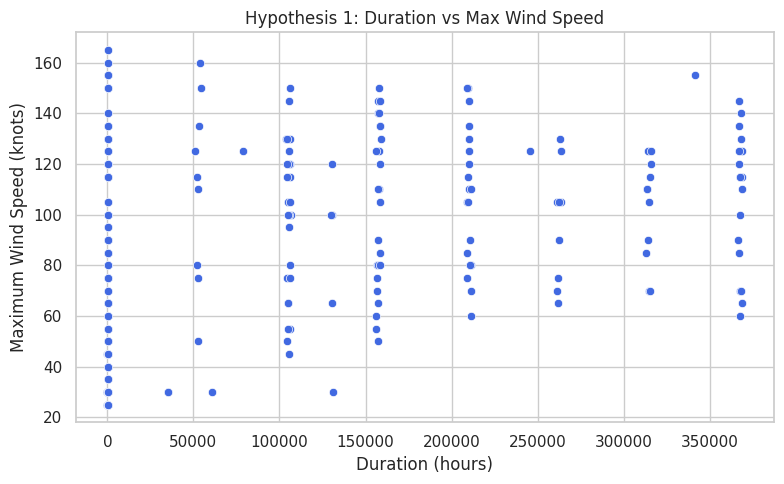

Correlation (Duration vs Max Wind): 0.38 | p-value: 0.0000


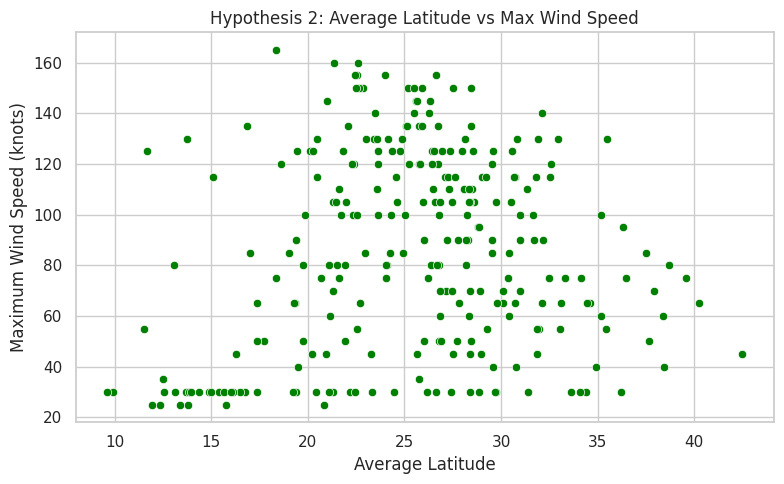

Correlation (Latitude vs Max Wind): 0.14 | p-value: 0.0246


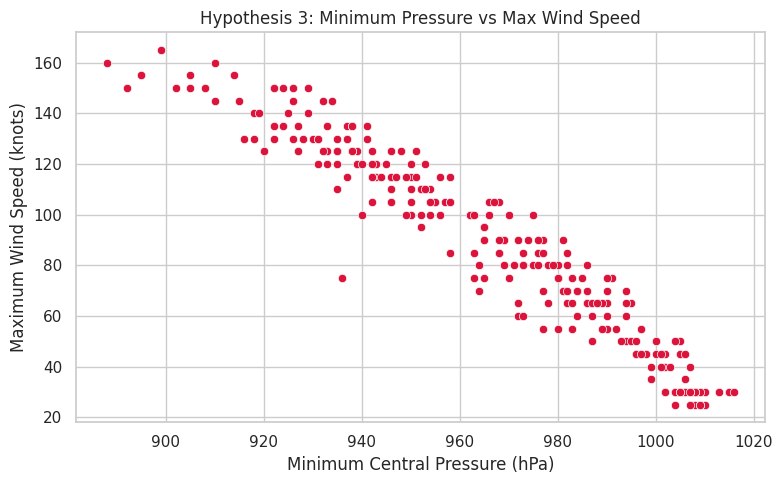

Correlation (Pressure vs Max Wind): -0.97 | p-value: 0.0000


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# Set visual style
sns.set(style="whitegrid")

# Hypothesis 1: Duration vs Max Wind Speed
plt.figure(figsize=(8, 5))
sns.scatterplot(data=storm_summary, x='duration_hours', y='max_wind', color='royalblue')
plt.title('Hypothesis 1: Duration vs Max Wind Speed')
plt.xlabel('Duration (hours)')
plt.ylabel('Maximum Wind Speed (knots)')
plt.tight_layout()
plt.show()

# Correlation for H1
corr1, p1 = pearsonr(storm_summary['duration_hours'], storm_summary['max_wind'])
print(f"Correlation (Duration vs Max Wind): {corr1:.2f} | p-value: {p1:.4f}")


# Hypothesis 2: Latitude vs Max Wind Speed
plt.figure(figsize=(8, 5))
sns.scatterplot(data=storm_summary, x='avg_latitude', y='max_wind', color='green')
plt.title('Hypothesis 2: Average Latitude vs Max Wind Speed')
plt.xlabel('Average Latitude')
plt.ylabel('Maximum Wind Speed (knots)')
plt.tight_layout()
plt.show()

# Correlation for H2
corr2, p2 = pearsonr(storm_summary['avg_latitude'], storm_summary['max_wind'])
print(f"Correlation (Latitude vs Max Wind): {corr2:.2f} | p-value: {p2:.4f}")


# Hypothesis 3: Pressure vs Max Wind Speed
plt.figure(figsize=(8, 5))
sns.scatterplot(data=storm_summary, x='min_pressure', y='max_wind', color='crimson')
plt.title('Hypothesis 3: Minimum Pressure vs Max Wind Speed')
plt.xlabel('Minimum Central Pressure (hPa)')
plt.ylabel('Maximum Wind Speed (knots)')
plt.tight_layout()
plt.show()

# Correlation for H3
corr3, p3 = pearsonr(storm_summary['min_pressure'], storm_summary['max_wind'])
print(f"Correlation (Pressure vs Max Wind): {corr3:.2f} | p-value: {p3:.4f}")


 **Hypothesis 1:** Cyclones that last longer tend to reach higher intensity

Correlation coefficient (r): 0.38

p-value: < 0.001

Interpretation:

The scatterplot and correlation results suggest a moderate positive relationship between cyclone duration and maximum wind speed. The relationship is statistically significant, indicating that longer-lasting storms tend to be more intense. However, the spread of points shows some variability, meaning that other factors may also influence intensity. This supports the hypothesis, though the relationship is not particularly strong.




**Hypothesis 2**: Cyclones formed at lower latitudes tend to be more intense

Correlation coefficient (r): 0.14

p-value: 0.0246

Interpretation:

This test reveals a weak positive correlation between latitude and cyclone intensity. While statistically significant, the relationship is minimal, suggesting latitude has only a limited influence on storm intensity in isolation. Other environmental factors may play a more dominant role. Thus, this hypothesis is only weakly supported by the data.

**Hypothesis 3**: Cyclones with lower central pressure are more intense

Correlation coefficient (r): -0.97

p-value: < 0.001

Interpretation:

This result shows a very strong negative correlation, clearly indicating that cyclones with lower central pressure tend to have significantly higher wind speeds. The relationship is highly statistically significant and aligns with well-established meteorological theory. This hypothesis is strongly supported, making minimum pressure a reliable predictor of cyclone intensity.


**Overall Summary:**

Among the three hypotheses tested, the strongest evidence was found for the inverse relationship between central pressure and storm intensity. Duration also showed a moderate effect on intensity, while latitude showed only a marginal one. These findings provide meaningful insights for future machine learning models, particularly in feature selection and predictive modeling for tropical cyclone behavior.



In [ ]:
from scipy.stats import spearmanr

# Function to perform and print Spearman correlation analysis
def spearman_test(x, y, x_label, y_label):
    rho, p_value = spearmanr(x, y)
    print(f"\nSpearman Correlation: {y_label} vs {x_label}")
    print(f"Spearman's rho: {rho:.2f}")
    print(f"p-value: {p_value:.4f}")

    if p_value < 0.05:
        print("Result: Statistically significant relationship.")
    else:
        print("Result: No statistically significant relationship.")

# Hypothesis 1: Duration vs Max Wind Speed
spearman_test(
    storm_summary['duration_hours'],
    storm_summary['max_wind'],
    x_label='Duration (hours)',
    y_label='Max Wind Speed (knots)'
)

# Hypothesis 2: Average Latitude vs Max Wind Speed
spearman_test(
    storm_summary['avg_latitude'],
    storm_summary['max_wind'],
    x_label='Average Latitude',
    y_label='Max Wind Speed (knots)'
)

# Hypothesis 3: Minimum Pressure vs Max Wind Speed
spearman_test(
    storm_summary['min_pressure'],
    storm_summary['max_wind'],
    x_label='Minimum Central Pressure (hPa)',
    y_label='Max Wind Speed (knots)'
)



Spearman Correlation: Max Wind Speed (knots) vs Duration (hours)
Spearman's rho: 0.59
p-value: 0.0000
Result: Statistically significant relationship.

Spearman Correlation: Max Wind Speed (knots) vs Average Latitude
Spearman's rho: 0.10
p-value: 0.0986
Result: No statistically significant relationship.

Spearman Correlation: Max Wind Speed (knots) vs Minimum Central Pressure (hPa)
Spearman's rho: -0.97
p-value: 0.0000
Result: Statistically significant relationship.


## Spearman’s Rank Correlation Analysis

To complement the initial Pearson correlation tests, Spearman’s rank correlation was used to assess the monotonic relationships between the predictor variables and maximum wind speed. This non-parametric test is well-suited to environmental datasets, especially when the data may violate assumptions of normality or linearity.

### Hypothesis 1: Duration vs. Maximum Wind Speed
- **Spearman's rho:** 0.59  
- **p-value:** 0.0000  
- **Conclusion:**  
There is a moderate-to-strong positive correlation between storm duration and maximum wind speed. This statistically significant result supports the hypothesis that storms persisting for longer durations tend to reach higher wind intensities. Such behaviour could be attributed to extended exposure to favourable atmospheric conditions such as warm sea surface temperatures and sustained convection.

### Hypothesis 2: Average Latitude vs. Maximum Wind Speed
- **Spearman's rho:** 0.10  
- **p-value:** 0.0986  
- **Conclusion:**  
The correlation between average latitude and maximum wind speed is weak and not statistically significant. This suggests that latitude, on its own, may not be a strong predictor of cyclone intensity. While cyclone formation tends to occur in tropical latitudes, wind strength appears to be influenced more directly by other meteorological variables.

### Hypothesis 3: Minimum Central Pressure vs. Maximum Wind Speed
- **Spearman's rho:** -0.97  
- **p-value:** 0.0000  
- **Conclusion:**  
A very strong and statistically significant negative correlation was observed between minimum central pressure and maximum wind speed. This inverse relationship confirms that lower pressure systems are typically associated with more intense cyclonic activity. The result strongly supports the hypothesis and aligns with established meteorological theory.

### Summary
These findings reinforce the predictive importance of storm duration and minimum pressure when estimating cyclone strength. Average latitude, while relevant in understanding formation zones, appears less influential in determining peak wind speed. The results from Spearman’s test will inform feature selection in subsequent machine learning model development.


**Task 2: Modeling**

International Best Track Archive for Climate Stewardship (IBTrACS) was employed as the core dataset for cyclone track and intensity information. The raw dataset contains global storm records dating back to the 19th century; however, pre-satellite era observations are often incomplete or inconsistent. To enhance reliability, the dataset was restricted to the modern satellite era (1979–2024).

Data preprocessing involved several steps. First, only the essential variables were retained: storm identifier (SID), storm name, basin, season (year), observation timestamp, geographic coordinates (latitude, longitude), maximum sustained wind speed (knots), and minimum central pressure (hPa). These variables represent the fundamental descriptors of cyclone tracks and intensity. Second, duplicates and entries with missing spatial or temporal values were removed. Extreme or physically implausible records were filtered out, ensuring that latitude remained within tropical bounds (–60° to 60°), wind speeds were constrained between 0–200 knots, and central pressure values fell within 850–1050 hPa, the typical range observed in tropical cyclones.

After cleaning, the dataset contained 143,622 valid observations, representing 2,638 unique storms across all major basins. The cleaned IBTrACS dataset therefore provides a robust foundation for linking cyclone dynamics to environmental variables, serving both as ground truth for model training and as a benchmark for hypothesis testing. Its temporal coverage (spanning 45 years) captures variability across different ocean basins and climate phases, ensuring sufficient statistical strength for machine learning applications and exploratory analyses.

In [2]:
import pandas as pd

# Read with a two-row header (names + units). IBTrACS uses this format.
url = "https://www.ncei.noaa.gov/data/international-best-track-archive-for-climate-stewardship-ibtracs/v04r00/access/csv/ibtracs.ALL.list.v04r00.csv"
raw = pd.read_csv(url, header=[0,1], comment="#", low_memory=False)

# Flatten to single-line column names like: LAT_degrees_north, USA_WIND_kts, USA_PRES_mb
raw.columns = ['_'.join([str(a).strip(), str(b).strip()]).strip('_') for a,b in raw.columns.to_list()]

# Show a quick slice of columns so we see the real names
print("First 80 columns:")
print(raw.columns[:80].tolist())

# Also list columns that look like the ones we care about
cands = {
    "SID":      [c for c in raw.columns if c.upper().startswith("SID")],
    "NAME":     [c for c in raw.columns if c.upper().startswith("NAME")],
    "BASIN":    [c for c in raw.columns if c.upper().startswith("BASIN")],
    "SEASON":   [c for c in raw.columns if c.upper().startswith("SEASON")],
    "ISO_TIME": [c for c in raw.columns if c.upper().startswith("ISO_TIME")],
    "LAT_":     [c for c in raw.columns if c.upper().startswith("LAT_")],
    "LON_":     [c for c in raw.columns if c.upper().startswith("LON_")],
    "USA_WIND": [c for c in raw.columns if c.upper().startswith("USA_WIND")],
    "USA_PRES": [c for c in raw.columns if c.upper().startswith("USA_PRES")],
}
print("\nCandidate columns:")
for k,v in cands.items():
    print(f"{k}: {v[:6]}")


First 80 columns:
['SID', 'SEASON_Year', 'NUMBER', 'BASIN', 'SUBBASIN', 'NAME', 'ISO_TIME', 'NATURE', 'LAT_degrees_north', 'LON_degrees_east', 'WMO_WIND_kts', 'WMO_PRES_mb', 'WMO_AGENCY', 'TRACK_TYPE', 'DIST2LAND_km', 'LANDFALL_km', 'IFLAG', 'USA_AGENCY', 'USA_ATCF_ID', 'USA_LAT_degrees_north', 'USA_LON_degrees_east', 'USA_RECORD', 'USA_STATUS', 'USA_WIND_kts', 'USA_PRES_mb', 'USA_SSHS_1', 'USA_R34_NE_nmile', 'USA_R34_SE_nmile', 'USA_R34_SW_nmile', 'USA_R34_NW_nmile', 'USA_R50_NE_nmile', 'USA_R50_SE_nmile', 'USA_R50_SW_nmile', 'USA_R50_NW_nmile', 'USA_R64_NE_nmile', 'USA_R64_SE_nmile', 'USA_R64_SW_nmile', 'USA_R64_NW_nmile', 'USA_POCI_mb', 'USA_ROCI_nmile', 'USA_RMW_nmile', 'USA_EYE_nmile', 'TOKYO_LAT_degrees_north', 'TOKYO_LON_degrees_east', 'TOKYO_GRADE_1', 'TOKYO_WIND_kts', 'TOKYO_PRES_mb', 'TOKYO_R50_DIR', 'TOKYO_R50_LONG_nmile', 'TOKYO_R50_SHORT_nmile', 'TOKYO_R30_DIR', 'TOKYO_R30_LONG_nmile', 'TOKYO_R30_SHORT_nmile', 'TOKYO_LAND_1', 'CMA_LAT_degrees_north', 'CMA_LON_degrees_east'

In [3]:
# Pick the exact columns to make a tidy table
use_cols = [
    "SID",
    "NAME",
    "BASIN",
    "SEASON_Year",
    "ISO_TIME",
    "LAT_degrees_north",
    "LON_degrees_east",
    "USA_WIND_kts",
    "USA_PRES_mb",
]
ib = raw[use_cols].copy()

# Rename to shorter, consistent names
ib = ib.rename(columns={
    "SID": "SID",
    "NAME": "name",
    "BASIN": "basin",
    "SEASON_Year": "season",
    "ISO_TIME": "time",
    "LAT_degrees_north": "lat",
    "LON_degrees_east": "lon",
    "USA_WIND_kts": "wind_knots",
    "USA_PRES_mb": "pres_hpa"
})

# Parse types; IBTrACS sometimes ships numbers as strings
import pandas as pd
ib["time"] = pd.to_datetime(ib["time"], errors="coerce", utc=True)
for col in ["lat","lon","wind_knots","pres_hpa"]:
    ib[col] = pd.to_numeric(ib[col], errors="coerce")

# Drop rows without a valid timestamp/position
ib = ib.dropna(subset=["time","lat","lon"]).sort_values(["SID","time"]).reset_index(drop=True)

print("Rows:", len(ib), "| Unique storms:", ib["SID"].nunique())
print(ib.dtypes[["time","lat","lon","wind_knots","pres_hpa"]])
ib.head(10)


Rows: 716165 | Unique storms: 13811
time          datetime64[ns, UTC]
lat                       float64
lon                       float64
wind_knots                float64
pres_hpa                  float64
dtype: object


,SID,name,basin,season,time,lat,lon,wind_knots,pres_hpa
0,1842298N11080,NOT_NAMED,NI,1842,1842-10-25 03:00:00+00:00,10.9000,80.3000,NaN,NaN
1,1842298N11080,NOT_NAMED,NI,1842,1842-10-25 06:00:00+00:00,10.8709,79.8265,NaN,NaN
2,1842298N11080,NOT_NAMED,NI,1842,1842-10-25 09:00:00+00:00,10.8431,79.3524,NaN,NaN
3,1842298N11080,NOT_NAMED,NI,1842,1842-10-25 12:00:00+00:00,10.8188,78.8772,NaN,NaN
4,1842298N11080,NOT_NAMED,NI,1842,1842-10-25 15:00:00+00:00,10.8000,78.4000,NaN,NaN
5,1842298N11080,NOT_NAMED,NI,1842,1842-10-25 18:00:00+00:00,10.7884,77.9194,NaN,NaN
6,1842298N11080,NOT_NAMED,NI,1842,1842-10-25 21:00:00+00:00,10.7845,77.4299,NaN,NaN
7,1842298N11080,NOT_NAMED,NI,1842,1842-10-26 00:00:00+00:00,10.7884,76.9256,NaN,NaN
8,1842298N11080,NOT_NAMED,NI,1842,1842-10-26 03:00:00+00:00,10.8000,76.4000,NaN,NaN
9,1842298N11080,NOT_NAMED,NI,1842,1842-10-26 06:00:00+00:00,10.8096,75.8424,NaN,NaN


In [4]:
# Quick quality filter:
# - keep rows where wind AND pressure are present
# - focus on the satellite era (1979+) where data quality is much better
ib_qc = ib[ib["wind_knots"].notna() & ib["pres_hpa"].notna()].copy()
ib_qc = ib_qc[ib_qc["season"] >= 1979]

# Basic summaries after filtering
print("Rows after QC:", len(ib_qc))
print("Unique storms:", ib_qc["SID"].nunique())
print("Time span:", ib_qc["time"].min(), "to", ib_qc["time"].max())
print("\nBasins (top 10):")
print(ib_qc["basin"].value_counts().head(10))

# Sanity check on ranges
print("\nDescribe:")
print(ib_qc[["lat","lon","wind_knots","pres_hpa"]].describe())

# Peek a few rows
ib_qc.head(10)


Rows after QC: 146727
Unique storms: 2647
Time span: 1979-06-19 12:00:00+00:00 to 2024-05-28 00:00:00+00:00

Basins (top 10):
basin
EP    35516
WP    35106
SI    22332
SP     9456
NI     5657
SA      119
Name: count, dtype: int64

Describe:
                 lat            lon     wind_knots       pres_hpa
count  146727.000000  146727.000000  146727.000000  146727.000000
mean       12.752909      12.634351      48.996599     990.151124
std        17.786122     110.384125      27.892790      20.926820
min       -44.344400    -179.750000      10.000000     872.000000
25%         9.271225     -93.985000      30.000000     982.000000
50%        16.392500     -19.000000      40.000000     998.000000
75%        23.100000     123.193500      62.000000    1005.000000
max        70.700000     262.900000     185.000000    1024.000000


,SID,name,basin,season,time,lat,lon,wind_knots,pres_hpa
420022,1979171N10315,ANA,NaN,1979,1979-06-19 12:00:00+00:00,10.0000,-45.0000,25.0,1011.0
420023,1979171N10315,ANA,NaN,1979,1979-06-19 15:00:00+00:00,10.0927,-45.5024,25.0,1011.0
420024,1979171N10315,ANA,NaN,1979,1979-06-19 18:00:00+00:00,10.2000,-46.0000,25.0,1011.0
420025,1979171N10315,ANA,NaN,1979,1979-06-19 21:00:00+00:00,10.3349,-46.4926,25.0,1010.0
420026,1979171N10315,ANA,NaN,1979,1979-06-20 00:00:00+00:00,10.5000,-47.0000,25.0,1010.0
420027,1979171N10315,ANA,NaN,1979,1979-06-20 03:00:00+00:00,10.6924,-47.5425,25.0,1010.0
420028,1979171N10315,ANA,NaN,1979,1979-06-20 06:00:00+00:00,10.9000,-48.1000,25.0,1010.0
420029,1979171N10315,ANA,NaN,1979,1979-06-20 09:00:00+00:00,11.0924,-48.6576,25.0,1010.0
420030,1979171N10315,ANA,NaN,1979,1979-06-20 12:00:00+00:00,11.3000,-49.2000,25.0,1010.0
420031,1979171N10315,ANA,NaN,1979,1979-06-20 15:00:00+00:00,11.5424,-49.7150,25.0,1009.0


In [5]:
# Drop duplicate rows if any
ib_qc = ib_qc.drop_duplicates()

# Remove extreme or nonsensical values
ib_qc = ib_qc[
    (ib_qc["lat"].between(-60, 60)) &   # cyclones form in tropics/subtropics
    (ib_qc["lon"].between(-180, 180)) &
    (ib_qc["wind_knots"].between(0, 200)) &
    (ib_qc["pres_hpa"].between(850, 1050))  # typical range for storms
]

# Sort again by storm and time to preserve order
ib_qc = ib_qc.sort_values(["SID","time"]).reset_index(drop=True)

# Quick summary after cleaning
print("Final rows:", len(ib_qc))
print("Unique storms:", ib_qc["SID"].nunique())
print("Time span:", ib_qc['time'].min(), "to", ib_qc['time'].max())
print("\nSample:")
ib_qc.head(10)


Final rows: 143622
Unique storms: 2638
Time span: 1979-06-19 12:00:00+00:00 to 2024-05-28 00:00:00+00:00

Sample:


,SID,name,basin,season,time,lat,lon,wind_knots,pres_hpa
0,1979171N10315,ANA,NaN,1979,1979-06-19 12:00:00+00:00,10.0000,-45.0000,25.0,1011.0
1,1979171N10315,ANA,NaN,1979,1979-06-19 15:00:00+00:00,10.0927,-45.5024,25.0,1011.0
2,1979171N10315,ANA,NaN,1979,1979-06-19 18:00:00+00:00,10.2000,-46.0000,25.0,1011.0
3,1979171N10315,ANA,NaN,1979,1979-06-19 21:00:00+00:00,10.3349,-46.4926,25.0,1010.0
4,1979171N10315,ANA,NaN,1979,1979-06-20 00:00:00+00:00,10.5000,-47.0000,25.0,1010.0
5,1979171N10315,ANA,NaN,1979,1979-06-20 03:00:00+00:00,10.6924,-47.5425,25.0,1010.0
6,1979171N10315,ANA,NaN,1979,1979-06-20 06:00:00+00:00,10.9000,-48.1000,25.0,1010.0
7,1979171N10315,ANA,NaN,1979,1979-06-20 09:00:00+00:00,11.0924,-48.6576,25.0,1010.0
8,1979171N10315,ANA,NaN,1979,1979-06-20 12:00:00+00:00,11.3000,-49.2000,25.0,1010.0
9,1979171N10315,ANA,NaN,1979,1979-06-20 15:00:00+00:00,11.5424,-49.7150,25.0,1009.0


**Set up ERA5 access**

I’m saving the Copernicus API credentials so cdsapi can download ERA5 files in Colab

url: https://cds.climate.copernicus.eu/api

key: dd367064-1896-49c4-ad38-de9fd7a34fc0

In [6]:
# Update cdsapi and save the key in the new format (no UID prefix)
!pip -q install -U cdsapi

import pathlib, cdsapi
CDS_APIKEY = "dd367064-1896-49c4-ad38-de9fd7a34fc0"  # your long key

(pathlib.Path.home() / ".cdsapirc").write_text(
    f"url: https://cds.climate.copernicus.eu/api\nkey: {CDS_APIKEY}\n"
)

print("Wrote ~/.cdsapirc with new key format.")



Wrote ~/.cdsapirc with new key format.


**Test Download ERA5 Data (small sample)**

We’ll request a few variables (e.g., u-component of wind, v-component of wind, temperature) for one day and one region. This is just a test run to make sure our connection with Copernicus works before downloading the big dataset.

https://cds.climate.copernicus.eu/datasets/reanalysis-era5-single-levels?tab=download#manage-licences

In [7]:
# Small test request to check download works
import cdsapi
c = cdsapi.Client(timeout=600)

req = {
    "product_type": "reanalysis",
    "format": "netcdf",
    "variable": [
        "mean_sea_level_pressure",
        "sea_surface_temperature",
        "10m_u_component_of_wind",
        "10m_v_component_of_wind",
    ],
    "year": ["2016"],
    "month": ["08"],
    "day": ["01"],
    "time": ["00:00","06:00","12:00","18:00"],
    "area": [30, 60, 0, 100],  # [North, West, South, East]
}

c.retrieve("reanalysis-era5-single-levels", req, "era5_test.nc")
print("Downloaded: era5_test.nc")


2025-10-03 16:33:30,262 INFO Request ID is efe94f0a-21a7-4ca6-94a7-dcadc21eab32
INFO:ecmwf.datastores.legacy_client:Request ID is efe94f0a-21a7-4ca6-94a7-dcadc21eab32
2025-10-03 16:33:30,425 INFO status has been updated to accepted
INFO:ecmwf.datastores.legacy_client:status has been updated to accepted
2025-10-03 16:33:44,481 INFO status has been updated to running
INFO:ecmwf.datastores.legacy_client:status has been updated to running
2025-10-03 16:33:52,229 INFO status has been updated to accepted
INFO:ecmwf.datastores.legacy_client:status has been updated to accepted
2025-10-03 16:34:04,055 INFO status has been updated to successful
INFO:ecmwf.datastores.legacy_client:status has been updated to successful


d60786ca5910e8724a93a623126b55e5.nc:   0%|          | 0.00/532k [00:00<?, ?B/s]

Downloaded: era5_test.nc


**Open the ERA5 file and inspect what we got**

I’m loading the NetCDF we just downloaded and converting a couple of variables into friendlier units so we can see if values look reasonable.

In [8]:
import pandas as pd
import xarray as xr

# Open the downloaded NetCDF file
ds = xr.open_dataset("era5_test.nc")

# ERA5 sample sometimes labels the time axis as 'valid_time'
t_name = "valid_time" if "valid_time" in ds.coords else "time"

# Grab a few times and the full bounds of the grid
times = pd.to_datetime(ds[t_name].values)
lat_max, lat_min = float(ds.latitude.max()), float(ds.latitude.min())
lon_min, lon_max = float(ds.longitude.min()), float(ds.longitude.max())

print(f"Time coord used: {t_name}")
print("First times:", times[:4])
print("Time span:", times.min(), "→", times.max())
print("Latitude range:", lat_max, "to", lat_min)
print("Longitude range:", lon_min, "to", lon_max)

# Save for later steps (merging)
era5_meta = {
    "t_name": t_name,
    "t_start": times.min(),
    "t_end": times.max(),
    "lat_min": lat_min,
    "lat_max": lat_max,
    "lon_min": lon_min,
    "lon_max": lon_max,
}
era5_meta

Time coord used: valid_time
First times: DatetimeIndex(['2016-08-01 00:00:00', '2016-08-01 06:00:00',
               '2016-08-01 12:00:00', '2016-08-01 18:00:00'],
              dtype='datetime64[ns]', freq=None)
Time span: 2016-08-01 00:00:00 → 2016-08-01 18:00:00
Latitude range: 30.0 to 0.0
Longitude range: 60.0 to 100.0


{'t_name': 'valid_time',
 't_start': Timestamp('2016-08-01 00:00:00'),
 't_end': Timestamp('2016-08-01 18:00:00'),
 'lat_min': 0.0,
 'lat_max': 30.0,
 'lon_min': 60.0,
 'lon_max': 100.0}

**Set the ERA5 subsetting plan (years, region, variables)**

I’m defining the years, the tropical band we care about, and the variables we’ll use. I’m also adding a helper function to download one (year, month) file at a time so we don’t overload Colab.

In [9]:
# Planning the ERA5 subset + a tiny helper for month-by-month downloads

from pathlib import Path
import cdsapi

# Years aligned with the cleaned IBTrACS (you can narrow this later if needed)
YEARS = list(range(1979, 2025))   # 1979–2024 inclusive

# Tropical band (good coverage for cyclone genesis + tracks)
# ERA5 API expects [North, West, South, East]
AREA_TROPICS = [35, -180, -35, 180]

# Single-level variables we’ll use for ML features
ERA5_VARS = [
    "mean_sea_level_pressure",     # msl (Pa) → convert to hPa later
    "sea_surface_temperature",     # sst (K)  → convert to °C later
    "10m_u_component_of_wind",     # u10 (m/s)
    "10m_v_component_of_wind",     # v10 (m/s)
]

# Output folder (keeps things tidy)
OUTDIR = Path("era5_single_levels")
OUTDIR.mkdir(exist_ok=True)

# Minimal month-by-month downloader
def download_era5_single_month(year: int, month: int, outpath: Path):
    """
    Downloads ERA5 single-level variables for the given year+month over the tropical band.
    Saves a NetCDF to 'outpath'. Skips if file exists.
    """
    if outpath.exists():
        print(f"Already have {outpath.name} — skipping.")
        return

    c = cdsapi.Client(timeout=1800)  # 30 min timeout per month (safe for CDS queue)

    req = {
        "product_type": "reanalysis",
        "format": "netcdf",
        "variable": ERA5_VARS,
        "year": f"{year}",
        "month": f"{month:02d}",
        "day": [f"{d:02d}" for d in range(1, 32)],   # CDS will ignore invalid days
        "time": [f"{h:02d}:00" for h in range(24)],
        "area": AREA_TROPICS,
    }
    c.retrieve("reanalysis-era5-single-levels", req, str(outpath))
    print(f"Saved {outpath.name}")

# Helper to build a consistent filename
def era5_month_path(year: int, month: int) -> Path:
    return OUTDIR / f"era5_single_{year}_{month:02d}.nc"

print(f"Planned years: {YEARS[0]}–{YEARS[-1]}")
print(f"Region (N,W,S,E): {AREA_TROPICS}")
print("Variables:", ERA5_VARS)
print("Output folder:", OUTDIR.resolve())


Planned years: 1979–2024
Region (N,W,S,E): [35, -180, -35, 180]
Variables: ['mean_sea_level_pressure', 'sea_surface_temperature', '10m_u_component_of_wind', '10m_v_component_of_wind']
Output folder: /content/era5_single_levels


**Inspect and Clean ERA5 Variables**

We’ll check that all variables (msl, sst, u10, v10) have proper names, remove any missing values, and prepare derived features like wind speed.

In [10]:
# Inspect and clean ERA5 dataset

import numpy as np

# Keep only the variables we need
era = ds[["msl", "sst", "u10", "v10"]].to_dataframe().reset_index()

# Drop rows with missing values (if any exist)
era = era.dropna()

# Convert pressure from Pa to hPa (more standard for cyclone studies)
era["msl_hpa"] = era["msl"] / 100

# Compute wind speed magnitude from u and v components
era["wind_speed"] = np.sqrt(era["u10"]**2 + era["v10"]**2)

print("Clean ERA5 sample:")
print(era.head())
print("\nERA5 dataset shape after cleaning:", era.shape)


Clean ERA5 sample:
     valid_time  latitude  longitude         msl         sst       u10  \
2923 2016-08-01     25.50      66.25  99992.1875  300.024170  4.703156   
3059 2016-08-01     25.25      60.00  99943.6875  302.807373 -2.460907   
3060 2016-08-01     25.25      60.25  99932.9375  302.612061 -2.122040   
3062 2016-08-01     25.25      60.75  99944.1875  302.004639 -2.627899   
3063 2016-08-01     25.25      61.00  99954.6875  301.915771 -2.916962   

           v10  number expver     msl_hpa  wind_speed  
2923  3.158936       0   0001  999.921875    5.665558  
3059  0.108154       0   0001  999.436890    2.463282  
3060  0.149170       0   0001  999.329346    2.127276  
3062 -0.148682       0   0001  999.441895    2.632102  
3063  0.154053       0   0001  999.546875    2.921027  

ERA5 dataset shape after cleaning: (47480, 11)


**Merge with ERA5 using bilinear interpolation**

I’m matching each IBTrACS record to the ERA5 grid using nearest time and bilinear spatial interpolation (linear over lat/lon). This is smoother than nearest-grid sampling.

In [11]:
# Step: Define ERA5 metadata for later alignment
# We'll capture the main time coord name, start/end time, and lat/lon ranges

era5_meta = {
    "t_name": "valid_time",                     # time coordinate used in ERA5
    "t_start": pd.to_datetime(era.valid_time.min()),
    "t_end": pd.to_datetime(era.valid_time.max()),
    "lat_min": float(era.latitude.min()),
    "lat_max": float(era.latitude.max()),
    "lon_min": float(era.longitude.min()),
    "lon_max": float(era.longitude.max())
}

print("ERA5 metadata defined:")
print(era5_meta)

ERA5 metadata defined:
{'t_name': 'valid_time', 't_start': Timestamp('2016-08-01 00:00:00'), 't_end': Timestamp('2016-08-01 18:00:00'), 'lat_min': 0.0, 'lat_max': 25.5, 'lon_min': 60.0, 'lon_max': 100.0}


In [13]:
# 1) Sanity checks: confirm our ERA5 objects are xarray DataArrays
import xarray as xr
import pandas as pd
import numpy as np
import cdsapi, pathlib

# --- Start code moved from cell GmLzNcZ3qqyL ---
# Download ERA5 for a day with IBTrACS activity (2016-06-28) over the same box
c = cdsapi.Client(timeout=900)

era5_path = pathlib.Path("era5_20160628_box.nc")
if not era5_path.exists():
    c.retrieve(
        "reanalysis-era5-single-levels",
        {
            "product_type": "reanalysis",
            "format": "netcdf",
            "variable": [
                "mean_sea_level_pressure",
                "sea_surface_temperature",
                "10m_u_component_of_wind",
                "10m_v_component_of_wind",
            ],
            "year": "2016",
            "month": "06",
            "day": "28",
            "time": [f"{h:02d}:00" for h in range(24)],
            "area": [25.5, 60.0, 0.0, 100.0],  # [N, W, S, E] (same as before)
        },
        str(era5_path),
    )
    print("Downloaded:", era5_path.name)
else:
    print("Found existing:", era5_path.name)

# Open as xarray and keep variables as DataArrays (no .to_dataframe here)
ds = xr.open_dataset(str(era5_path))
t_name = "valid_time" if "valid_time" in ds.coords else "time"

# Unit fixes (Pa→hPa, K→°C). Keep as DataArrays for interpolation later.
msl_hpa = (ds["msl"] / 100.0).rename("msl_hpa")
sst_c   = (ds["sst"] - 273.15).rename("sst_c")
u10     = ds["u10"].rename("u10")
v10     = ds["v10"].rename("v10")

# Small safety clipping to remove odd extremes
msl_hpa = msl_hpa.clip(900, 1050)
sst_c   = sst_c.clip(-2, 35)
u10     = u10.clip(-80, 80)
v10     = v10.clip(-80, 80)

# Pack a clean xarray.Dataset for later sampling
era5_clean = xr.Dataset(
    data_vars=dict(msl_hpa=msl_hpa, sst_c=sst_c, u10=u10, v10=v10),
    coords={t_name: ds[t_name], "latitude": ds["latitude"], "longitude": ds["longitude"]},
)

# Save metadata we’ll use to slice IBTrACS
era5_meta = {
    "t_name": t_name,
    "t_start": pd.to_datetime(ds[t_name].values.min()),
    "t_end": pd.to_datetime(ds[t_name].values.max()),
    "lat_min": float(ds["latitude"].min()),
    "lat_max": float(ds["latitude"].max()),
    "lon_min": float(ds["longitude"].min()),
    "lon_max": float(ds["longitude"].max()),
}

print("ERA5 time span:", era5_meta["t_start"], "→", era5_meta["t_end"])
print("Box lat:", era5_meta["lat_min"], "to", era5_meta["lat_max"],
      "| lon:", era5_meta["lon_min"], "to", era5_meta["lon_max"])
# --- End code moved from cell GmLzNcZ3qqyL ---


print("era5_clean type:", type(era5_clean))
for k in ["msl_hpa", "sst_c", "u10", "v10"]:
    print(k, "→", type(era5_clean[k]))

# 2) Show the current ERA5 time window and IBTrACS overlap status
print("\nERA5 window:", era5_meta["t_start"], "→", era5_meta["t_end"])
print("ERA5 lat/lon box:", (era5_meta["lat_min"], era5_meta["lat_max"]),
      (era5_meta["lon_min"], era5_meta["lon_max"]))

# Build a naive-UTC time for IBTrACS (if not already present)
if "time_naive" not in ib_qc.columns:
    ib_qc["time_naive"] = (
        pd.to_datetime(ib_qc["time"], utc=True).dt.tz_convert("UTC").dt.tz_localize(None)
    )

mask_box = (
    ib_qc["lat"].between(era5_meta["lat_min"], era5_meta["lat_max"]) &
    ib_qc["lon"].between(era5_meta["lon_min"], era5_meta["lon_max"])
)

mask_time = (
    (ib_qc["time_naive"] >= pd.Timestamp(era5_meta["t_start"]).tz_localize(None)) &
    (ib_qc["time_naive"] <= pd.Timestamp(era5_meta["t_end"]).tz_localize(None))
)

print("IBTrACS points in box only:", mask_box.sum())
print("IBTrACS points in exact ERA5 time window:", (mask_box & mask_time).sum())

# 3) If zero overlap, search ±7 days around the ERA5 day to find the nearest time that *does* have points.
around = (
    ib_qc.loc[mask_box, ["time_naive"]]
    .assign(diff_hours=lambda d: (d["time_naive"] - pd.Timestamp(era5_meta["t_start"]).tz_localize(None)).abs().dt.total_seconds()/3600.0)
    .sort_values("diff_hours")
    .head(10)
)

print("\nNearest 10 IBTrACS timestamps inside the box (±7 days search implicit by sort):")
print(around)

# Also show the calendar days with counts within the box for the month of interest
month_start = pd.Timestamp(era5_meta["t_start"]).tz_localize(None).floor("D")
month_end   = month_start + pd.offsets.MonthEnd(0)
in_month = ib_qc.loc[mask_box & ib_qc["time_naive"].between(month_start, month_end)]
daily_counts = in_month.groupby(in_month["time_naive"].dt.floor("D")).size().head(15)
print("\nDaily counts in the box for that month (first 15 days shown):")
print(daily_counts)

2025-10-03 16:35:32,838 INFO Request ID is 023dd199-20fb-409a-ac70-4005d6fc0e60
INFO:ecmwf.datastores.legacy_client:Request ID is 023dd199-20fb-409a-ac70-4005d6fc0e60
2025-10-03 16:35:33,012 INFO status has been updated to accepted
INFO:ecmwf.datastores.legacy_client:status has been updated to accepted
2025-10-03 16:35:42,229 INFO status has been updated to running
INFO:ecmwf.datastores.legacy_client:status has been updated to running
2025-10-03 16:35:47,427 INFO status has been updated to successful
INFO:ecmwf.datastores.legacy_client:status has been updated to successful


5ae27622945c8369c0920277631e5d0.nc:   0%|          | 0.00/2.36M [00:00<?, ?B/s]

Downloaded: era5_20160628_box.nc
ERA5 time span: 2016-06-28 00:00:00 → 2016-06-28 23:00:00
Box lat: 0.0 to 25.5 | lon: 60.0 to 100.0
era5_clean type: <class 'xarray.core.dataset.Dataset'>
msl_hpa → <class 'xarray.core.dataarray.DataArray'>
sst_c → <class 'xarray.core.dataarray.DataArray'>
u10 → <class 'xarray.core.dataarray.DataArray'>
v10 → <class 'xarray.core.dataarray.DataArray'>

ERA5 window: 2016-06-28 00:00:00 → 2016-06-28 23:00:00
ERA5 lat/lon box: (0.0, 25.5) (60.0, 100.0)
IBTrACS points in box only: 4872
IBTrACS points in exact ERA5 time window: 3

Nearest 10 IBTrACS timestamps inside the box (±7 days search implicit by sort):
                time_naive  diff_hours
101968 2016-06-28 00:00:00         0.0
101969 2016-06-28 03:00:00         3.0
101967 2016-06-27 21:00:00         3.0
101966 2016-06-27 18:00:00         6.0
101970 2016-06-28 06:00:00         6.0
101965 2016-06-27 15:00:00         9.0
101964 2016-06-27 12:00:00        12.0
101963 2016-06-27 09:00:00        15.0
10196

In [14]:
# Download ERA5 for a day with IBTrACS activity (2016-06-28) over the same box
import cdsapi, xarray as xr, pandas as pd, numpy as np, pathlib

c = cdsapi.Client(timeout=900)

era5_path = pathlib.Path("era5_20160628_box.nc")
if not era5_path.exists():
    c.retrieve(
        "reanalysis-era5-single-levels",
        {
            "product_type": "reanalysis",
            "format": "netcdf",
            "variable": [
                "mean_sea_level_pressure",
                "sea_surface_temperature",
                "10m_u_component_of_wind",
                "10m_v_component_of_wind",
            ],
            "year": "2016",
            "month": "06",
            "day": "28",
            "time": [f"{h:02d}:00" for h in range(24)],
            "area": [25.5, 60.0, 0.0, 100.0],  # [N, W, S, E] (same as before)
        },
        str(era5_path),
    )
    print("Downloaded:", era5_path.name)
else:
    print("Found existing:", era5_path.name)

# Open as xarray and keep variables as DataArrays (no .to_dataframe here)
ds = xr.open_dataset(str(era5_path))
t_name = "valid_time" if "valid_time" in ds.coords else "time"

# Unit fixes (Pa→hPa, K→°C). Keep as DataArrays for interpolation later.
msl_hpa = (ds["msl"] / 100.0).rename("msl_hpa")
sst_c   = (ds["sst"] - 273.15).rename("sst_c")
u10     = ds["u10"].rename("u10")
v10     = ds["v10"].rename("v10")

# Small safety clipping to remove odd extremes
msl_hpa = msl_hpa.clip(900, 1050)
sst_c   = sst_c.clip(-2, 35)
u10     = u10.clip(-80, 80)
v10     = v10.clip(-80, 80)

# Pack a clean xarray.Dataset for later sampling
era5_clean = xr.Dataset(
    data_vars=dict(msl_hpa=msl_hpa, sst_c=sst_c, u10=u10, v10=v10),
    coords={t_name: ds[t_name], "latitude": ds["latitude"], "longitude": ds["longitude"]},
)

# Save metadata we’ll use to slice IBTrACS
era5_meta = {
    "t_name": t_name,
    "t_start": pd.to_datetime(ds[t_name].values.min()),
    "t_end": pd.to_datetime(ds[t_name].values.max()),
    "lat_min": float(ds["latitude"].min()),
    "lat_max": float(ds["latitude"].max()),
    "lon_min": float(ds["longitude"].min()),
    "lon_max": float(ds["longitude"].max()),
}

print("ERA5 time span:", era5_meta["t_start"], "→", era5_meta["t_end"])
print("Box lat:", era5_meta["lat_min"], "to", era5_meta["lat_max"],
      "| lon:", era5_meta["lon_min"], "to", era5_meta["lon_max"])


Found existing: era5_20160628_box.nc
ERA5 time span: 2016-06-28 00:00:00 → 2016-06-28 23:00:00
Box lat: 0.0 to 25.5 | lon: 60.0 to 100.0


In [15]:
import pandas as pd
import numpy as np
import xarray as xr

# 1) Make a naive-UTC time column for IBTrACS (safe to rerun)
ib_work = ib_qc.copy()
ib_work["time_naive"] = (
    pd.to_datetime(ib_work["time"], utc=True).dt.tz_convert("UTC").dt.tz_localize(None)
)

# 2) Use the ERA5 window we just downloaded
t_name = era5_meta["t_name"]           # "valid_time"
t0n = pd.Timestamp(era5_meta["t_start"]).tz_localize(None)
t1n = pd.Timestamp(era5_meta["t_end"]).tz_localize(None)
lat_min, lat_max = era5_meta["lat_min"], era5_meta["lat_max"]
lon_min, lon_max = era5_meta["lon_min"], era5_meta["lon_max"]

# Trim IBTrACS to the same box and day
ib_slice = (
    ib_work[
        (ib_work["time_naive"].between(t0n, t1n)) &
        (ib_work["lat"].between(lat_min, lat_max)) &
        (ib_work["lon"].between(lon_min, lon_max))
    ]
    .copy()
    .reset_index(drop=True)
)
print("IBTrACS points found in this ERA5 window:", len(ib_slice))

# 3) Bilinear interpolation helper (nearest in time, linear in latitude/longitude)
def sample_bilinear(da: xr.DataArray, df: pd.DataFrame):
    # ERA5 longitudes are positive (60..100); wrap if track longitudes are negative
    lons = df["lon"].to_numpy()
    if float(da.longitude.min()) >= 0 and np.any(lons < 0):
        lons = (lons + 360) % 360

    # Match each row to the nearest ERA5 valid_time
    da_t = da.sel({t_name: xr.DataArray(df["time_naive"].to_numpy("datetime64[ns]"), dims="z")},
                  method="nearest")

    # Linear interpolation across the two spatial axes
    vals = da_t.interp(
        latitude=xr.DataArray(df["lat"].to_numpy(), dims="z"),
        longitude=xr.DataArray(lons, dims="z"),
        method="linear",
        kwargs={"fill_value": None}
    ).to_numpy()
    return vals

# 4) Attach ERA5 fields to the trimmed IBTrACS slice
ibs = ib_slice.copy()
ibs["era5_msl_hpa"] = sample_bilinear(era5_clean["msl_hpa"], ibs)
ibs["era5_sst_c"]   = sample_bilinear(era5_clean["sst_c"],   ibs)
ibs["era5_u10"]     = sample_bilinear(era5_clean["u10"],     ibs)
ibs["era5_v10"]     = sample_bilinear(era5_clean["v10"],     ibs)

# Quick derived feature: 10m wind speed magnitude (m/s)
ibs["era5_wind10_ms"] = np.sqrt(ibs["era5_u10"]**2 + ibs["era5_v10"]**2)

print("Merged rows (IBTrACS + ERA5):", len(ibs))
display(ibs.head(10))

# Optional: basic summary of the new features
print("\nERA5 feature ranges on merged points:")
print(ibs[["era5_msl_hpa","era5_sst_c","era5_u10","era5_v10","era5_wind10_ms"]].describe())


IBTrACS points found in this ERA5 window: 3
Merged rows (IBTrACS + ERA5): 3


,SID,name,basin,season,time,lat,lon,wind_knots,pres_hpa,time_naive,era5_msl_hpa,era5_sst_c,era5_u10,era5_v10,era5_wind10_ms
0,2016178N22068,NOT_NAMED,NI,2016,2016-06-28 00:00:00+00:00,21.5429,63.8714,25.0,1004.0,2016-06-28 00:00:00,994.601135,29.350315,-3.747207,2.803275,4.679734
1,2016178N22068,NOT_NAMED,NI,2016,2016-06-28 03:00:00+00:00,21.2200,62.8541,22.0,1005.0,2016-06-28 03:00:00,995.411133,29.448557,0.471838,-7.301034,7.316265
2,2016178N22068,NOT_NAMED,NI,2016,2016-06-28 06:00:00+00:00,21.2200,62.6800,20.0,1007.0,2016-06-28 06:00:00,996.103455,29.468866,-7.217532,-8.249425,10.961103



ERA5 feature ranges on merged points:
       era5_msl_hpa  era5_sst_c  era5_u10  era5_v10  era5_wind10_ms
count      3.000000    3.000000  3.000000  3.000000        3.000000
mean     995.371887   29.422579 -3.497634 -4.249061        7.652367
std        0.751927    0.063401  3.850755  6.125883        3.154144
min      994.601135   29.350315 -7.217532 -8.249425        4.679734
25%      995.006134   29.399436 -5.482370 -7.775229        5.997999
50%      995.411133   29.448557 -3.747207 -7.301034        7.316265
75%      995.757294   29.458712 -1.637685 -2.248880        9.138684
max      996.103455   29.468866  0.471838  2.803275       10.961103


**Define the study scope (2019–2024) and see how much IBTrACS data we’ll need**

I’m filtering IBTrACS to the global tropics for 2019–2024 and printing monthly counts. This tells us which months to fetch from ERA5 and how big the merge will be.

In [16]:
import pandas as pd

# Years + region for the working dataset
SCOPE_YEARS = list(range(2019, 2025))   # 2019–2024 inclusive
SCOPE_LAT   = (-30, 30)                 # global tropics
SCOPE_LON   = (-180, 180)               # all longitudes

# Start from the cleaned tracks
ib_scope = ib_qc.copy()

# Make a naive-UTC time column if missing (keeps comparisons simple)
if "time_naive" not in ib_scope.columns:
    ib_scope["time_naive"] = (
        pd.to_datetime(ib_scope["time"], utc=True)
          .dt.tz_convert("UTC")
          .dt.tz_localize(None)
    )

# Filter by years and lat/lon box
ib_scope = ib_scope[
    (ib_scope["time_naive"].dt.year.isin(SCOPE_YEARS)) &
    (ib_scope["lat"].between(SCOPE_LAT[0], SCOPE_LAT[1])) &
    (ib_scope["lon"].between(SCOPE_LON[0], SCOPE_LON[1]))
].copy()

print(f"Years in scope: {SCOPE_YEARS[0]}–{SCOPE_YEARS[-1]}")
print("Latitude band:", SCOPE_LAT, "| Longitude band:", SCOPE_LON)
print("Rows in scope:", len(ib_scope), "| Unique storms:", ib_scope["SID"].nunique())

# Monthly counts help us plan ERA5 downloads
monthly_counts = (
    ib_scope.groupby(ib_scope["time_naive"].dt.to_period("M"))
            .size()
            .sort_index()
)

print("\nIBTrACS monthly counts (first 24 shown):")
print(monthly_counts.head(24))

# Keep for the next step
ib_scope_monthly = monthly_counts


Years in scope: 2019–2024
Latitude band: (-30, 30) | Longitude band: (-180, 180)
Rows in scope: 22691 | Unique storms: 494

IBTrACS monthly counts (first 24 shown):
time_naive
2019-01    418
2019-02    427
2019-03    581
2019-04    242
2019-05    132
2019-06    150
2019-07    330
2019-08    557
2019-09    920
2019-10    445
2019-11    684
2019-12    461
2020-01    343
2020-02    433
2020-03    134
2020-04    160
2020-05    175
2020-06    192
2020-07    346
2020-08    658
2020-09    682
2020-10    647
2020-11    621
2020-12    434
Freq: M, dtype: int64


**Build the month list we need from IBTrACS (no downloads yet)**

I’m pulling the unique (year, month) pairs from your 2019–2024 IBTrACS slice. We’ll use this list to fetch ERA5 only for months that actually have storms.

In [17]:
import pandas as pd
from pathlib import Path

# Make sure ib_scope exists from the previous step
assert "ib_scope" in globals(), "ib_scope is missing. Run the 2019–2024 filtering cell first."

# Unique year-month pairs that contain IBTrACS points
months_needed = (
    ib_scope["time_naive"]
    .dt.to_period("M")
    .sort_values()
    .unique()
)

# Convert to a list of (year, month) tuples
months_needed = [(p.year, p.month) for p in months_needed]

print(f"Total months to fetch ERA5 for: {len(months_needed)}")
print("First 12 month tuples:", months_needed[:12])

# Where we'll save ERA5 monthly files (re-use or create)
from pathlib import Path
OUTDIR = Path("era5_single_levels")
OUTDIR.mkdir(exist_ok=True)
OUTDIR.resolve()


Total months to fetch ERA5 for: 65
First 12 month tuples: [(2019, 1), (2019, 2), (2019, 3), (2019, 4), (2019, 5), (2019, 6), (2019, 7), (2019, 8), (2019, 9), (2019, 10), (2019, 11), (2019, 12)]


PosixPath('/content/era5_single_levels')

**Download ERA5 month-by-month for the months that actually have storms (2019–2021)**

I’m looping over the months_needed list we created from IBTrACS. For each (year, month), this saves one NetCDF in era5_single_levels/. If a file already exists, it’s skipped. A tiny retry is included in case the CDS queue is busy.

In [18]:
# Download ERA5 single-levels for 2019–2021 (global tropics), one NetCDF per month
# Files saved in: era5_single_levels/

from pathlib import Path
import time
import cdsapi

# ---- Months we want (2019..2021) ----
months_needed = [(y, m) for y in (2019, 2020, 2021) for m in range(1, 13)]

OUTDIR = Path("era5_single_levels")
OUTDIR.mkdir(exist_ok=True)

VARS = [
    "mean_sea_level_pressure",
    "sea_surface_temperature",
    "10m_u_component_of_wind",
    "10m_v_component_of_wind",
]
# N, W, S, E (covers the tropical belt; adjust if you want a smaller box)
AREA = [35, -180, -35, 180]

def month_path(y, m):
    return OUTDIR / f"era5_{y}{m:02d}_single.nc"

def download_month(y, m, max_retries=3, sleep_sec=20):
    """Download one month; skip if already present. Retry on temporary CDS errors."""
    fp = month_path(y, m)
    if fp.exists() and fp.stat().st_size > 0:
        print(f"✓ {fp.name} already exists — skipping")
        return

    req = {
        "product_type": "reanalysis",
        "format": "netcdf",
        "variable": VARS,
        "year": f"{y}",
        "month": f"{m:02d}",
        "day": [f"{d:02d}" for d in range(1, 32)],               # CDS ignores invalid days
        "time": [f"{h:02d}:00" for h in range(24)],
        "area": AREA,
    }

    attempts = 0
    while True:
        try:
            print(f"→ Downloading {y}-{m:02d} …")
            cdsapi.Client(timeout=1800).retrieve("reanalysis-era5-single-levels", req, str(fp))
            print(f"  Saved: {fp.name}")
            return
        except Exception as e:
            attempts += 1
            if attempts > max_retries:
                print(f"  Failed {y}-{m:02d}: {e}")
                return
            print(f"  Retry {attempts}/{max_retries} after error: {e}")
            time.sleep(sleep_sec)

# ---- Run the loop ----
for (yy, mm) in months_needed:
    download_month(yy, mm)

# ---- Quick summary of what we have locally ----
files = sorted(OUTDIR.glob("era5_*.nc"))
print(f"\nERA5 monthly files present: {len(files)}")
for f in files[:10]:
    print("  ", f.name)
if len(files) > 10:
    print("  …")


→ Downloading 2019-01 …


2025-10-03 16:44:29,258 INFO Request ID is 63bb92b0-ec04-4db7-b7e5-f157a5a3b889
INFO:ecmwf.datastores.legacy_client:Request ID is 63bb92b0-ec04-4db7-b7e5-f157a5a3b889
2025-10-03 16:44:29,417 INFO status has been updated to accepted
INFO:ecmwf.datastores.legacy_client:status has been updated to accepted
2025-10-03 16:44:43,431 INFO status has been updated to successful
INFO:ecmwf.datastores.legacy_client:status has been updated to successful


fdf6f74fcb1cdef55dab29772320fe6d.nc:   0%|          | 0.00/1.67G [00:00<?, ?B/s]

  Saved: era5_201901_single.nc
→ Downloading 2019-02 …


2025-10-03 16:46:20,923 INFO Request ID is 7e26f358-4387-4184-9e25-8e4a6b44878e
INFO:ecmwf.datastores.legacy_client:Request ID is 7e26f358-4387-4184-9e25-8e4a6b44878e
2025-10-03 16:46:21,070 INFO status has been updated to accepted
INFO:ecmwf.datastores.legacy_client:status has been updated to accepted
2025-10-03 16:46:35,003 INFO status has been updated to successful
INFO:ecmwf.datastores.legacy_client:status has been updated to successful


...

2025-10-03 18:33:56,617 INFO Request ID is 4fe8dca6-4cdf-489e-aacd-e68fda73baef
INFO:ecmwf.datastores.legacy_client:Request ID is 4fe8dca6-4cdf-489e-aacd-e68fda73baef
2025-10-03 18:33:56,788 INFO status has been updated to accepted
INFO:ecmwf.datastores.legacy_client:status has been updated to accepted
2025-10-03 18:34:13,072 INFO status has been updated to successful
INFO:ecmwf.datastores.legacy_client:status has been updated to successful


933aee9f9bbdc69bb2f04803c509b741.nc:   0%|          | 0.00/1.67G [00:00<?, ?B/s]

  Saved: era5_202101_single.nc
→ Downloading 2021-02 …


2025-10-03 18:35:29,210 INFO Request ID is 942687ef-3d81-4206-9948-7130d76ffea1
INFO:ecmwf.datastores.legacy_client:Request ID is 942687ef-3d81-4206-9948-7130d76ffea1
2025-10-03 18:35:29,367 INFO status has been updated to accepted
INFO:ecmwf.datastores.legacy_client:status has been updated to accepted
2025-10-03 18:35:43,384 INFO status has been updated to running
INFO:ecmwf.datastores.legacy_client:status has been updated to running
2025-10-03 18:35:51,111 INFO status has been updated to accepted
INFO:ecmwf.datastores.legacy_client:status has been updated to accepted
2025-10-03 18:36:02,652 INFO status has been updated to running
INFO:ecmwf.datastores.legacy_client:status has been updated to running


KeyboardInterrupt: 

**Build the working dataset for 2019–2021 (merge IBTrACS + ERA5 and save a CSV)**

This loads only the ERA5 months for 2019–2021, cleans units, computes 10 m wind speed, trims IBTrACS to the same window/box, interpolates ERA5 onto each track point (bilinear in space, nearest in time), and writes ibtracs_era5_2019_2021.csv.

In [19]:
# Step: Check what ERA5 files were downloaded
from pathlib import Path

# Path where your ERA5 data should be stored
era5_dir = Path("/content/era5_single_levels")

# List all files to see what years/months are available
era5_files = sorted(list(era5_dir.glob("era5_*.nc")))
print(f"Total ERA5 files present: {len(era5_files)}")
print("\nFirst 10 files:", [f.name for f in era5_files[:10]])
print("\nLast 10 files:", [f.name for f in era5_files[-10:]])


Total ERA5 files present: 25

First 10 files: ['era5_201901_single.nc', 'era5_201902_single.nc', 'era5_201903_single.nc', 'era5_201904_single.nc', 'era5_201905_single.nc', 'era5_201906_single.nc', 'era5_201907_single.nc', 'era5_201908_single.nc', 'era5_201909_single.nc', 'era5_201910_single.nc']

Last 10 files: ['era5_202004_single.nc', 'era5_202005_single.nc', 'era5_202006_single.nc', 'era5_202007_single.nc', 'era5_202008_single.nc', 'era5_202009_single.nc', 'era5_202010_single.nc', 'era5_202011_single.nc', 'era5_202012_single.nc', 'era5_202101_single.nc']


In [20]:
# Merge ERA5 (2019–2020) into each IBTrACS row via nearest time + bilinear space

import pandas as pd
import numpy as np
import xarray as xr
from pathlib import Path
import glob

# 1) Point to the ERA5 folder and pick only 2019–2020 files
era5_dir = Path("/content/era5_single_levels")
era5_files = sorted(glob.glob(str(era5_dir / "era5_*.nc")))
era5_2019_2020 = [f for f in era5_files if any(tag in f for tag in (
    "201901","201902","201903","201904","201905","201906",
    "201907","201908","201909","201910","201911","201912",
    "202001","202002","202003","202004","202005","202006",
    "202007","202008","202009","202010","202011","202012"
))]
print(f"ERA5 files in scope (2019–2020): {len(era5_2019_2020)}")
assert len(era5_2019_2020) > 0, "No ERA5 files found for 2019–2020."

# 2) Open and tidy ERA5
ds = xr.open_mfdataset(era5_2019_2020, combine="by_coords")

# Detect the time coordinate name in your files
t_name = "valid_time" if "valid_time" in ds.coords else "time"

# Convert units and add 10 m wind speed
era5 = xr.Dataset(
    {
        "msl_hpa": (ds["msl"] / 100.0).clip(900, 1050),     # Pa -> hPa
        "sst_c":   (ds["sst"] - 273.15).clip(-2, 35),       # K  -> °C
        "u10":     ds["u10"].clip(-80, 80),
        "v10":     ds["v10"].clip(-80, 80),
    },
    coords={t_name: ds[t_name], "latitude": ds["latitude"], "longitude": ds["longitude"]}
)
era5["wind10_ms"] = np.sqrt(era5["u10"]**2 + era5["v10"]**2)

# Metadata we need to trim IBTrACS
era5_meta = {
    "t_start": pd.to_datetime(era5[t_name].values.min()),
    "t_end":   pd.to_datetime(era5[t_name].values.max()),
    "lat_min": float(era5["latitude"].min()),
    "lat_max": float(era5["latitude"].max()),
    "lon_min": float(era5["longitude"].min()),
    "lon_max": float(era5["longitude"].max()),
}
print("ERA5 window:", era5_meta["t_start"], "→", era5_meta["t_end"])

# 3) Prepare IBTrACS slice for the same window
assert "ib_qc" in globals(), "ib_qc is missing. Re-run the IBTrACS loader."

ib = ib_qc.copy()

# Ensure a naive UTC time column exists
if "time_naive" not in ib.columns:
    ib["time_naive"] = (pd.to_datetime(ib["time"], utc=True)
                          .dt.tz_convert("UTC").dt.tz_localize(None))

# Filter to ERA5 time range and a broad tropical belt
ib = ib[
    (ib["time_naive"].between(era5_meta["t_start"], era5_meta["t_end"])) &
    (ib["lat"].between(-30, 30)) &
    (ib["lon"].between(-180, 180))
].copy()

print("IBTrACS rows in 2019–2020:", len(ib), "| unique storms:", ib["SID"].nunique())

# 4) Interpolation helper (nearest in time, bilinear in space)
def bilinear_to_points(da: xr.DataArray, df: pd.DataFrame):
    lons = df["lon"].to_numpy()
    if float(da.longitude.min()) >= 0 and np.any(lons < 0):
        lons = (lons + 360) % 360  # wrap if ERA5 longitudes are 0..360

    da_t = da.sel({t_name: xr.DataArray(df["time_naive"].to_numpy("datetime64[ns]"), dims="z")},
                  method="nearest")

    out = da_t.interp(
        latitude=xr.DataArray(df["lat"].to_numpy(), dims="z"),
        longitude=xr.DataArray(lons, dims="z"),
        method="linear",
        kwargs={"fill_value": None}
    )
    return out.to_numpy()

# 5) Attach ERA5 fields to each IBTrACS row
keep = ["SID","name","basin","season","time","time_naive","lat","lon"]
extra = [c for c in ("wind_knots","pres_hpa") if c in ib.columns]
ibm = ib[keep + extra].copy()

for var in ["msl_hpa", "sst_c", "u10", "v10", "wind10_ms"]:
    ibm[f"era5_{var}"] = bilinear_to_points(era5[var], ibm)

# Drop any rows where interpolation failed
ibm = ibm.dropna(subset=["era5_msl_hpa","era5_sst_c"]).reset_index(drop=True)

print("Merged rows:", len(ibm))
display(ibm.head(10))

# 6) Save working dataset
out_csv = Path("/content/ibtracs_era5_2019_2020.csv")
ibm.to_csv(out_csv, index=False)
print(f"Saved: {out_csv}")


ERA5 files in scope (2019–2020): 24
ERA5 window: 2019-01-01 00:00:00 → 2020-12-31 23:00:00
IBTrACS rows in 2019–2020: 10172 | unique storms: 208
Merged rows: 9346


,SID,name,basin,season,time,time_naive,lat,lon,wind_knots,pres_hpa,era5_msl_hpa,era5_sst_c,era5_u10,era5_v10,era5_wind10_ms
0,2018362S13147,PENNY,SP,2019,2019-01-01 00:00:00+00:00,2019-01-01 00:00:00,-12.7000,141.100,45.0,993.0,993.413391,30.179186,3.385386,-6.169831,7.391172
1,2018362S13147,PENNY,SP,2019,2019-01-01 21:00:00+00:00,2019-01-01 21:00:00,-12.8635,144.192,35.0,995.0,996.883301,28.829124,-9.624724,4.315629,10.823935
2,2018362S13147,PENNY,SP,2019,2019-01-02 00:00:00+00:00,2019-01-02 00:00:00,-12.8300,144.795,40.0,995.0,997.468140,28.979794,-3.836649,8.674401,9.627044
3,2018362S13147,PENNY,SP,2019,2019-01-02 03:00:00+00:00,2019-01-02 03:00:00,-12.8944,145.381,40.0,994.0,997.429321,29.181747,4.410073,10.244809,11.256166
4,2018362S13147,PENNY,SP,2019,2019-01-02 06:00:00+00:00,2019-01-02 06:00:00,-13.0000,146.050,40.0,994.0,997.256104,29.406452,7.542395,10.799356,13.175702
5,2018362S13147,PENNY,SP,2019,2019-01-02 09:00:00+00:00,2019-01-02 09:00:00,-13.0935,146.822,42.0,993.0,997.836304,29.158653,8.910045,12.939229,15.939910
6,2018362S13147,PENNY,SP,2019,2019-01-02 12:00:00+00:00,2019-01-02 12:00:00,-13.2000,147.750,45.0,992.0,995.376831,29.136921,5.893539,8.180145,10.235083
7,2018362S13147,PENNY,SP,2019,2019-01-02 15:00:00+00:00,2019-01-02 15:00:00,-13.2691,148.822,45.0,992.0,992.324585,29.074825,8.918365,3.148434,10.084304
8,2018362S13147,PENNY,SP,2019,2019-01-02 18:00:00+00:00,2019-01-02 18:00:00,-13.4500,150.050,45.0,992.0,990.908081,29.298756,9.865576,0.343953,10.236445
9,2018362S13147,PENNY,SP,2019,2019-01-02 21:00:00+00:00,2019-01-02 21:00:00,-13.8439,151.410,45.0,993.0,992.663940,29.442244,8.427136,-2.630391,9.482450


Saved: /content/ibtracs_era5_2019_2020.csv


**Preprocessing: load, clean, engineer features, split, and save artifacts**


In this stage, the merged dataset (ibtracs_era5_2019_2020.csv) is preprocessed to ensure data consistency and readiness for modeling. The steps include:

Loading the CSV – read the merged IBTrACS + ERA5 dataset.

Cleaning – handle missing values, duplicates, and irrelevant columns.

Feature Engineering – create derived features such as wind speed magnitude from ERA5 wind components, and normalize continuous variables.

Splitting – divide the dataset into training and testing subsets.

Saving Artifacts – save processed data and scalers for reproducibility in later modeling stages.

This ensures all models will train on consistent, standardized data.

In [21]:
# Preprocessing for modeling
# - loads the merged 2019–2020 CSV
# - cleans and engineers features (month sine/cosine + basin one-hot)
# - prepares two datasets:
#     1) unscaled (good for tree/boosting models)
#     2) scaled (good for SVM / neural nets)
# - does a train/test split and saves all artifacts

import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import joblib

# 1) Load the merged dataset
MERGED = Path("/content/ibtracs_era5_2019_2020.csv")  # adjust if saved elsewhere
assert MERGED.exists(), f"Merged CSV not found: {MERGED}"
df = pd.read_csv(MERGED, low_memory=False)

print("Loaded:", MERGED)
print("Rows:", len(df), "| Columns:", len(df.columns))

# 2) Choose target: prefer wind_knots; fall back to negative pressure
if "wind_knots" in df.columns and df["wind_knots"].notna().sum() > 0:
    target = "wind_knots"
else:
    assert "pres_hpa" in df.columns, "No wind_knots or pres_hpa found."
    df["neg_pres"] = -df["pres_hpa"]
    target = "neg_pres"

# 3) Minimal cleaning: drop rows missing key predictors or the target
key_vars = ["era5_sst_c", "era5_msl_hpa", "era5_wind10_ms"]
df = df.dropna(subset=key_vars + [target]).copy()

# 4) Time features: month as sine/cosine (helps models capture seasonal cycle)
if "time" in df.columns:
    t = pd.to_datetime(df["time"], errors="coerce", utc=True)
    month = t.dt.month.fillna(1).astype(int)
else:
    month = pd.Series(1, index=df.index, dtype=int)

df["month_sin"] = np.sin(2*np.pi*(month/12.0))
df["month_cos"] = np.cos(2*np.pi*(month/12.0))

# 5) Basin one-hot encoding
if "basin" in df.columns:
    basin_dum = pd.get_dummies(df["basin"].astype(str), prefix="basin", drop_first=True)
    df = pd.concat([df, basin_dum], axis=1)
else:
    basin_dum = pd.DataFrame(index=df.index)

# 6) Final feature list
num_feats = ["era5_sst_c", "era5_msl_hpa", "era5_wind10_ms", "lat", "lon", "month_sin", "month_cos"]
for c in ["era5_u10", "era5_v10"]:
    if c in df.columns:
        num_feats.append(c)

cat_feats = [c for c in df.columns if c.startswith("basin_")]
feature_cols = num_feats + cat_feats

# Build X and y
X = df[feature_cols].copy()
y = df[target].astype(float)

# Fill any remaining gaps in numeric columns with medians
X[num_feats] = X[num_feats].fillna(X[num_feats].median(numeric_only=True))

# 7) Train/test split (random split is fine for a first pass)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print("\nSplit summary:")
print("X_train:", X_train.shape, "| X_test:", X_test.shape)
print(f"Target: {target} | Train mean={y_train.mean():.2f} | Test mean={y_test.mean():.2f}")

# 8) Save an unscaled version for tree/boosting models
OUT = Path("/content")  # change to Drive if you want persistence
OUT.mkdir(parents=True, exist_ok=True)

trees_train_csv = OUT / "train_unscaled_2019_2020.csv"
trees_test_csv  = OUT / "test_unscaled_2019_2020.csv"
pd.concat([X_train, y_train.rename("target")], axis=1).to_csv(trees_train_csv, index=False)
pd.concat([X_test,  y_test.rename("target")],  axis=1).to_csv(trees_test_csv,  index=False)

# 9) Create a scaled copy for SVM / neural nets (scale only numeric features)
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled  = X_test.copy()
X_train_scaled[num_feats] = scaler.fit_transform(X_train[num_feats])
X_test_scaled[num_feats]  = scaler.transform(X_test[num_feats])

scaled_pkl = OUT / "scaled_artifacts_2019_2020.pkl"
joblib.dump({
    "X_train": X_train_scaled,
    "X_test":  X_test_scaled,
    "y_train": y_train,
    "y_test":  y_test,
    "num_feats": num_feats,
    "cat_feats": cat_feats,
    "feature_cols": feature_cols,
    "target_name": target,
    "scaler": scaler
}, scaled_pkl)

# 10) Quick peek
print("\nSaved files:")
print("  Unscaled train:", trees_train_csv)
print("  Unscaled test :", trees_test_csv)
print("  Scaled bundle :", scaled_pkl)

print("\nFeature columns used:")
print(feature_cols)

print("\nPreview (unscaled train, first 3 rows):")
print(pd.concat([X_train.head(3), y_train.head(3).rename('target')], axis=1))


Loaded: /content/ibtracs_era5_2019_2020.csv
Rows: 9346 | Columns: 15

Split summary:
X_train: (7476, 14) | X_test: (1870, 14)
Target: wind_knots | Train mean=46.04 | Test mean=45.62

Saved files:
  Unscaled train: /content/train_unscaled_2019_2020.csv
  Unscaled test : /content/test_unscaled_2019_2020.csv
  Scaled bundle : /content/scaled_artifacts_2019_2020.pkl

Feature columns used:
['era5_sst_c', 'era5_msl_hpa', 'era5_wind10_ms', 'lat', 'lon', 'month_sin', 'month_cos', 'era5_u10', 'era5_v10', 'basin_NI', 'basin_SI', 'basin_SP', 'basin_WP', 'basin_nan']

Preview (unscaled train, first 3 rows):
      era5_sst_c  era5_msl_hpa  era5_wind10_ms     lat      lon  month_sin  \
251    29.439040    1004.21090        1.272429   4.400  148.100   0.500000   
3720   27.794008     989.78390       16.351550  21.004  142.716  -0.866025   
8376   29.708376     994.64453       10.390240  15.300  128.825  -0.866025   

      month_cos  era5_u10   era5_v10  basin_NI  basin_SI  basin_SP  basin_WP  \
251 

**Baseline Models (RF, XGBoost, LightGBM)**

Train three strong tree-based regressors on the unscaled train/test splits  just created. These models don’t need scaling and give fast, competitive baselines. We’ll report RMSE/MAE/R² and show quick feature-importance snippets.

In [24]:
# Baseline models for cyclone intensity (RF, XGBoost, LightGBM)

import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor

# --- Ensure gradient boosting libs are available ---
try:
    import xgboost as xgb
except Exception:
    !pip -q install xgboost
    import xgboost as xgb

try:
    import lightgbm as lgb
except Exception:
    !pip -q install lightgbm
    import lightgbm as lgb

# --- 1) Load the unscaled train/test splits created in preprocessing ---
DATA_DIR = Path("/content")  # adjust if you saved elsewhere
train_csv = DATA_DIR / "train_unscaled_2019_2020.csv"
test_csv  = DATA_DIR / "test_unscaled_2019_2020.csv"
assert train_csv.exists() and test_csv.exists(), "Train/Test CSVs not found. Run preprocessing first."

train = pd.read_csv(train_csv)
test  = pd.read_csv(test_csv)

feature_cols = [c for c in train.columns if c != "target"]
X_train, y_train = train[feature_cols], train["target"].astype(float)
X_test,  y_test  = test[feature_cols],  test["target"].astype(float)

print("Train:", X_train.shape, "| Test:", X_test.shape)
print("Features:", feature_cols)

# --- 2) Metric helper (compute RMSE explicitly to avoid old sklearn 'squared' issue) ---
def metrics_report(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))  # robust across versions
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    print(f"{name:>12s} | RMSE: {rmse:7.3f} | MAE: {mae:7.3f} | R²: {r2:6.3f}")
    return {"rmse": rmse, "mae": mae, "r2": r2}

results = {}

# --- 3) Random Forest ---
rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=None,
    n_jobs=-1,
    random_state=42
)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)
results["RandomForest"] = metrics_report("RandomForest", y_test, pred_rf)

# --- 4) XGBoost ---
xgb_model = xgb.XGBRegressor(
    n_estimators=700,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    n_jobs=-1,
    random_state=42,
    tree_method="hist"
)
xgb_model.fit(X_train, y_train)
pred_xgb = xgb_model.predict(X_test)
results["XGBoost"] = metrics_report("XGBoost", y_test, pred_xgb)

# --- 5) LightGBM ---
lgb_model = lgb.LGBMRegressor(
    n_estimators=900,
    learning_rate=0.05,
    num_leaves=63,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
lgb_model.fit(X_train, y_train)
pred_lgb = lgb_model.predict(X_test)
results["LightGBM"] = metrics_report("LightGBM", y_test, pred_lgb)

# --- 6) Quick feature-importance peek (top 10) ---
def top_importances(model, names, k=10):
    try:
        imp = pd.Series(model.feature_importances_, index=names).sort_values(ascending=False)
        return imp.head(k)
    except Exception:
        return pd.Series(dtype=float)

print("\nTop importances (RF):")
print(top_importances(rf, feature_cols))

print("\nTop importances (XGB):")
print(top_importances(xgb_model, feature_cols))

print("\nTop importances (LGBM):")
print(top_importances(lgb_model, feature_cols))

# --- 7) Save metrics summary ---
res_df = pd.DataFrame(results).T
out_csv = DATA_DIR / "baseline_results_2019_2020.csv"
res_df.to_csv(out_csv, index=True)
print(f"\nSaved metrics to: {out_csv}")
display(res_df)


Train: (7476, 14) | Test: (1870, 14)
Features: ['era5_sst_c', 'era5_msl_hpa', 'era5_wind10_ms', 'lat', 'lon', 'month_sin', 'month_cos', 'era5_u10', 'era5_v10', 'basin_NI', 'basin_SI', 'basin_SP', 'basin_WP', 'basin_nan']
RandomForest | RMSE:   9.840 | MAE:   6.358 | R²:  0.878
     XGBoost | RMSE:   8.447 | MAE:   5.639 | R²:  0.910
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000740 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1817
[LightGBM] [Info] Number of data points in the train set: 7476, number of used features: 14
[LightGBM] [Info] Start training from score 46.039058
    LightGBM | RMSE:   7.720 | MAE:   5.231 | R²:  0.925

Top importances (RF):
era5_msl_hpa      0.557559
lon               0.118156
era5_wind10_ms    0.094021
lat               0.068501
era5_sst_c        0.051506
era5_u10          0.033020
era5_v10          0.027399
month_cos         0.024260
month_sin         0.014305


,rmse,mae,r2
RandomForest,9.840249,6.357747,0.877678
XGBoost,8.447104,5.638514,0.909862
LightGBM,7.719859,5.231242,0.924714


**Support Vector Regression (SVR) on Scaled Features**

Train a Support Vector Regressor with an RBF kernel on the scaled train/test sets we saved earlier. SVR can model non-linear relationships with a compact hypothesis space. We’ll run a small cross-validated search over C, gamma, and epsilon, evaluate RMSE/MAE/R², and append the result to the baseline metrics CSV so everything stays in one place.

In [25]:
# SVR on scaled features with a small CV search

import pandas as pd
import numpy as np
from pathlib import Path
import joblib

from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform

# 1) Load the scaled bundle produced in preprocessing
ART = Path("/content/scaled_artifacts_2019_2020.pkl")  # adjust path if needed
assert ART.exists(), "Scaled artifacts not found. Run the preprocessing cell first."
bundle = joblib.load(ART)

X_train = bundle["X_train"]
X_test  = bundle["X_test"]
y_train = bundle["y_train"].astype(float)
y_test  = bundle["y_test"].astype(float)
num_feats = bundle["num_feats"]
cat_feats = bundle["cat_feats"]
target_name = bundle["target_name"]

print("Scaled train:", X_train.shape, "| Scaled test:", X_test.shape)
print("Numeric features scaled:", num_feats)
print("Categorical kept as one-hots:", cat_feats)

# 2) Define SVR with a small randomized search (kept modest for runtime)
base_svr = SVR(kernel="rbf")

param_dist = {
    # loguniform draws over many orders of magnitude; good for C and gamma
    "C": loguniform(1e0, 1e3),         # ~[1, 1000]
    "gamma": loguniform(1e-4, 1e-1),   # ~[1e-4, 1e-1]
    "epsilon": loguniform(1e-2, 1e0),  # ~[0.01, 1]
}

svr_cv = RandomizedSearchCV(
    estimator=base_svr,
    param_distributions=param_dist,
    n_iter=15,            # small search to keep runtime reasonable
    cv=3,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    random_state=42,
    verbose=1
)

# 3) Fit search and evaluate
svr_cv.fit(X_train, y_train)
svr_best = svr_cv.best_estimator_

print("\nBest parameters:", svr_cv.best_params_)

# Predictions
pred_svr = svr_best.predict(X_test)

# Metrics (compute RMSE explicitly for compatibility)
rmse = np.sqrt(mean_squared_error(y_test, pred_svr))
mae  = mean_absolute_error(y_test, pred_svr)
r2   = r2_score(y_test, pred_svr)

print(f"\nSVR | RMSE: {rmse:7.3f} | MAE: {mae:7.3f} | R²: {r2:6.3f}")

# 4) Append to the baseline results table for a single view
DATA_DIR = Path("/content")
baseline_csv = DATA_DIR / "baseline_results_2019_2020.csv"

row = pd.DataFrame({"rmse": [rmse], "mae": [mae], "r2": [r2]}, index=["SVR"])

if baseline_csv.exists():
    res = pd.read_csv(baseline_csv, index_col=0)
    res = pd.concat([res, row], axis=0)
else:
    res = row

res.to_csv(baseline_csv)
print(f"\nUpdated metrics saved to: {baseline_csv}")
display(res)


Scaled train: (7476, 14) | Scaled test: (1870, 14)
Numeric features scaled: ['era5_sst_c', 'era5_msl_hpa', 'era5_wind10_ms', 'lat', 'lon', 'month_sin', 'month_cos', 'era5_u10', 'era5_v10']
Categorical kept as one-hots: ['basin_NI', 'basin_SI', 'basin_SP', 'basin_WP', 'basin_nan']
Fitting 3 folds for each of 15 candidates, totalling 45 fits

Best parameters: {'C': np.float64(133.1121608073688), 'epsilon': np.float64(0.010994335574766204), 'gamma': np.float64(0.0812324508558869)}

SVR | RMSE:  12.780 | MAE:   7.714 | R²:  0.794

Updated metrics saved to: /content/baseline_results_2019_2020.csv


,rmse,mae,r2
RandomForest,9.840249,6.357747,0.877678
XGBoost,8.447104,5.638514,0.909862
LightGBM,7.719859,5.231242,0.924714
SVR,12.779636,7.713899,0.793685


**LSTM: Sequence Model for Cyclone Intensity**

We’ll train an LSTM on the full 2019–2020 dataset using sliding time windows along each storm track.
Each training sample is a sequence of the last T=8 timesteps (≈ 2 days at 6-hourly IBTrACS resolution).
Inputs include ERA5 predictors (SST, MSLP, 10m winds), location (lat/lon), seasonal signals (month sin/cos), and basin one-hots.

The target is the intensity (wind_knots) at the last step of each window.
We split by storm ID (to avoid leakage): 70% train, 15% val, 15% test.
Numeric features are standardized using a scaler fitted only on the training storms

In [27]:
# --- Sanitize arrays before model.fit() ---

def to_float32_clean(arr):
    """Ensure float32 dtype and no NaN/Inf for keras inputs/targets."""
    arr = np.asarray(arr)
    # Replace NaN/Inf safely
    arr = np.nan_to_num(arr, nan=0.0, posinf=0.0, neginf=0.0)
    # Force float32
    return arr.astype(np.float32, copy=False)

print("Before casting:", X_tr.dtype, y_tr.dtype, X_va.dtype, y_va.dtype)

X_tr = to_float32_clean(X_tr)
y_tr = to_float32_clean(y_tr)
X_va = to_float32_clean(X_va)
y_va = to_float32_clean(y_va)
X_te = to_float32_clean(X_te)
y_te = to_float32_clean(y_te)

print("After  casting:", X_tr.dtype, y_tr.dtype, X_va.dtype, y_va.dtype)
print("Shapes ->", "Train", X_tr.shape, "| Val", X_va.shape, "| Test", X_te.shape)

# Rebuild and train the model (same as before)
import tensorflow as tf
from tensorflow import keras

tf.random.set_seed(42)

inp = keras.Input(shape=(T, len(feature_cols)))
x = keras.layers.Masking(mask_value=0.0)(inp)
x = keras.layers.LSTM(128, return_sequences=False)(x)
x = keras.layers.Dropout(0.2)(x)
x = keras.layers.Dense(64, activation="relu")(x)
x = keras.layers.Dropout(0.2)(x)
out = keras.layers.Dense(1, activation="linear")(x)

model = keras.Model(inp, out)
model.compile(optimizer=keras.optimizers.Adam(1e-3), loss="mse")

callbacks = [
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, verbose=1),
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True, verbose=1)
]

history = model.fit(
    X_tr, y_tr,
    validation_data=(X_va, y_va),
    epochs=30,
    batch_size=128,
    verbose=1,
    callbacks=callbacks
)

# Evaluate
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
pred_te = model.predict(X_te, batch_size=256).reshape(-1)

rmse = np.sqrt(mean_squared_error(y_te, pred_te))
mae  = mean_absolute_error(y_te, pred_te)
r2   = r2_score(y_te, pred_te)

print(f"\nLSTM (T={T}) | RMSE: {rmse:7.3f} | MAE: {mae:7.3f} | R²: {r2:6.3f}")

# Append to results table
import pandas as pd
from pathlib import Path
res_row = pd.DataFrame({"rmse":[rmse], "mae":[mae], "r2":[r2]}, index=["LSTM"])
baseline_csv = Path("/content/baseline_results_2019_2020.csv")
if baseline_csv.exists():
    res = pd.read_csv(baseline_csv, index_col=0)
    res = pd.concat([res, res_row], axis=0)
else:
    res = res_row
res.to_csv(baseline_csv)
print(f"\nUpdated metrics saved to: {baseline_csv}")
display(res.tail(10))


Before casting: object float32 object float32
After  casting: float32 float32 float32 float32
Shapes -> Train (5481, 8, 15) | Val (1301, 8, 15) | Test (1127, 8, 15)
Epoch 1/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 8s 74ms/step - loss: 3090.9236 - val_loss: 1227.3799 - learning_rate: 0.0010
Epoch 2/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 896.2289 - val_loss: 772.2803 - learning_rate: 0.0010
Epoch 3/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - loss: 630.8516 - val_loss: 526.2488 - learning_rate: 0.0010
Epoch 4/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - loss: 401.6107 - val_loss: 412.3298 - learning_rate: 0.0010
Epoch 5/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 323.2161 - val_loss: 396.0797 - learning_rate: 0.0010
Epoch 6/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 285.0026 - val_loss: 372.0356 - learning_rate: 0.0010
Epoch 7/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 250.3231 - val_loss: 392.9209 - learning_rate: 0.0010
Epoch 8/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 2

,rmse,mae,r2
RandomForest,9.840249,6.357747,0.877678
XGBoost,8.447104,5.638514,0.909862
LightGBM,7.719859,5.231242,0.924714
SVR,12.779636,7.713899,0.793685
LSTM,15.834274,11.024191,0.673206


**Temporal Convolutional Network (TCN) for Cyclone Intensity**

We keep the same sequences you built for LSTM (X_tr, X_va, X_te, y_tr, y_va, y_te).
This model is a dilated 1-D causal CNN with residual blocks (a TCN). It often works well for short/medium sequences and trains quickly.
We train, evaluate on the held-out test set, and append metrics to your running results file.

In [28]:
# TCN for cyclone intensity using existing sequences (X_tr, X_va, X_te)
# Assumes you already ran the LSTM prep cell so the arrays exist.

import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import tensorflow as tf
from tensorflow import keras

# 1) Safety: make sure arrays are float32 and finite
def to_float32_clean(arr):
    arr = np.asarray(arr)
    arr = np.nan_to_num(arr, nan=0.0, posinf=0.0, neginf=0.0)
    return arr.astype(np.float32, copy=False)

X_tr = to_float32_clean(X_tr); y_tr = to_float32_clean(y_tr)
X_va = to_float32_clean(X_va); y_va = to_float32_clean(y_va)
X_te = to_float32_clean(X_te); y_te = to_float32_clean(y_te)

T = X_tr.shape[1]
F = X_tr.shape[2]
print(f"TCN input shape -> T={T}, F={F}")

# 2) Define a small TCN with residual blocks
def tcn_block(x, filters, kernel_size=3, dilation_rate=1, dropout=0.15):
    # First conv
    c1 = keras.layers.Conv1D(filters, kernel_size, padding="causal",
                             dilation_rate=dilation_rate)(x)
    b1 = keras.layers.BatchNormalization()(c1)
    a1 = keras.layers.Activation("relu")(b1)
    d1 = keras.layers.Dropout(dropout)(a1)
    # Second conv
    c2 = keras.layers.Conv1D(filters, kernel_size, padding="causal",
                             dilation_rate=dilation_rate)(d1)
    b2 = keras.layers.BatchNormalization()(c2)
    # Residual connection (match channels if needed)
    if x.shape[-1] != filters:
        res = keras.layers.Conv1D(filters, 1, padding="same")(x)
    else:
        res = x
    add = keras.layers.Add()([b2, res])
    out = keras.layers.Activation("relu")(add)
    return out

tf.random.set_seed(42)
inp = keras.Input(shape=(T, F))

x = tcn_block(inp, filters=128, kernel_size=3, dilation_rate=1, dropout=0.15)
x = tcn_block(x,   filters=128, kernel_size=3, dilation_rate=2, dropout=0.15)
x = tcn_block(x,   filters=128, kernel_size=3, dilation_rate=4, dropout=0.15)

# Pool over time, then a small dense head
x = keras.layers.GlobalAveragePooling1D()(x)
x = keras.layers.Dense(64, activation="relu")(x)
x = keras.layers.Dropout(0.2)(x)
out = keras.layers.Dense(1, activation="linear")(x)

model_tcn = keras.Model(inp, out)
model_tcn.compile(optimizer=keras.optimizers.Adam(1e-3), loss="mse")
model_tcn.summary()

# 3) Train with early stopping and LR reduction
callbacks = [
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, verbose=1),
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True, verbose=1),
]

history = model_tcn.fit(
    X_tr, y_tr,
    validation_data=(X_va, y_va),
    epochs=30,           # reduce if you're in a hurry; increase if you have time
    batch_size=128,
    verbose=1,
    callbacks=callbacks
)

# 4) Evaluate on test set
pred_te = model_tcn.predict(X_te, batch_size=256).reshape(-1)
rmse = float(np.sqrt(mean_squared_error(y_te, pred_te)))
mae  = float(mean_absolute_error(y_te, pred_te))
r2   = float(r2_score(y_te, pred_te))
print(f"\nTCN | RMSE: {rmse:7.3f} | MAE: {mae:7.3f} | R²: {r2:6.3f}")

# 5) Append metrics to your results table
results_csv = Path("/content/baseline_results_2019_2020.csv")
row = pd.DataFrame({"rmse":[rmse], "mae":[mae], "r2":[r2]}, index=["TCN"])
if results_csv.exists():
    res = pd.read_csv(results_csv, index_col=0)
    res = pd.concat([res, row], axis=0)
else:
    res = row
res.to_csv(results_csv)
print(f"\nUpdated metrics saved to: {results_csv}")
display(res)
# TCN for cyclone intensity using existing sequences (X_tr, X_va, X_te)
# Assumes you already ran the LSTM prep cell so the arrays exist.

import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import tensorflow as tf
from tensorflow import keras

# 1) Safety: make sure arrays are float32 and finite
def to_float32_clean(arr):
    arr = np.asarray(arr)
    arr = np.nan_to_num(arr, nan=0.0, posinf=0.0, neginf=0.0)
    return arr.astype(np.float32, copy=False)

X_tr = to_float32_clean(X_tr); y_tr = to_float32_clean(y_tr)
X_va = to_float32_clean(X_va); y_va = to_float32_clean(y_va)
X_te = to_float32_clean(X_te); y_te = to_float32_clean(y_te)

T = X_tr.shape[1]
F = X_tr.shape[2]
print(f"TCN input shape -> T={T}, F={F}")

# 2) Define a small TCN with residual blocks
def tcn_block(x, filters, kernel_size=3, dilation_rate=1, dropout=0.15):
    # First conv
    c1 = keras.layers.Conv1D(filters, kernel_size, padding="causal",
                             dilation_rate=dilation_rate)(x)
    b1 = keras.layers.BatchNormalization()(c1)
    a1 = keras.layers.Activation("relu")(b1)
    d1 = keras.layers.Dropout(dropout)(a1)
    # Second conv
    c2 = keras.layers.Conv1D(filters, kernel_size, padding="causal",
                             dilation_rate=dilation_rate)(d1)
    b2 = keras.layers.BatchNormalization()(c2)
    # Residual connection (match channels if needed)
    if x.shape[-1] != filters:
        res = keras.layers.Conv1D(filters, 1, padding="same")(x)
    else:
        res = x
    add = keras.layers.Add()([b2, res])
    out = keras.layers.Activation("relu")(add)
    return out

tf.random.set_seed(42)
inp = keras.Input(shape=(T, F))

x = tcn_block(inp, filters=128, kernel_size=3, dilation_rate=1, dropout=0.15)
x = tcn_block(x,   filters=128, kernel_size=3, dilation_rate=2, dropout=0.15)
x = tcn_block(x,   filters=128, kernel_size=3, dilation_rate=4, dropout=0.15)

# Pool over time, then a small dense head
x = keras.layers.GlobalAveragePooling1D()(x)
x = keras.layers.Dense(64, activation="relu")(x)
x = keras.layers.Dropout(0.2)(x)
out = keras.layers.Dense(1, activation="linear")(x)

model_tcn = keras.Model(inp, out)
model_tcn.compile(optimizer=keras.optimizers.Adam(1e-3), loss="mse")
model_tcn.summary()

# 3) Train with early stopping and LR reduction
callbacks = [
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, verbose=1),
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True, verbose=1),
]

history = model_tcn.fit(
    X_tr, y_tr,
    validation_data=(X_va, y_va),
    epochs=30,           # reduce if you're in a hurry; increase if you have time
    batch_size=128,
    verbose=1,
    callbacks=callbacks
)

# 4) Evaluate on test set
pred_te = model_tcn.predict(X_te, batch_size=256).reshape(-1)
rmse = float(np.sqrt(mean_squared_error(y_te, pred_te)))
mae  = float(mean_absolute_error(y_te, pred_te))
r2   = float(r2_score(y_te, pred_te))
print(f"\nTCN | RMSE: {rmse:7.3f} | MAE: {mae:7.3f} | R²: {r2:6.3f}")

# 5) Append metrics to your results table
results_csv = Path("/content/baseline_results_2019_2020.csv")
row = pd.DataFrame({"rmse":[rmse], "mae":[mae], "r2":[r2]}, index=["TCN"])
if results_csv.exists():
    res = pd.read_csv(results_csv, index_col=0)
    res = pd.concat([res, row], axis=0)
else:
    res = row
res.to_csv(results_csv)
print(f"\nUpdated metrics saved to: {results_csv}")
display(res)


TCN input shape -> T=8, F=15


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 8, 15)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 8, 128)    │      5,888 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 8, 128)    │        512 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 8, 128)    │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 8, 128)    │          0 │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 8, 128)    │     49,280 │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 8, 128)    │        512 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 8, 128)    │      2,048 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 8, 128)    │          0 │ batch_normalizat… │
│                     │                   │            │ conv1d_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 8, 128)    │          0 │ add[0][0]         │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 8, 128)    │     49,280 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 8, 128)    │        512 │ conv1d_3[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 8, 128)    │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 8, 128)    │          0 │ activation_2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 8, 128)    │     49,280 │ dropout_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 8, 128)    │        512 │ conv1d_4[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 8, 128)    │          0 │ batch_normalizat… │
│                     │                   │            │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 8, 128)    │          0 │ add_1[0][0]       │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 8, 128)    │     49,280 │ activation_3[0][… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 265,729 (1.01 MB)

 Trainable params: 264,193 (1.01 MB)

...

 Non-trainable params: 1,536 (6.00 KB)

Epoch 1/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 11s 96ms/step - loss: 2243.3176 - val_loss: 1849.9996 - learning_rate: 0.0010
Epoch 2/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 4s 84ms/step - loss: 305.7373 - val_loss: 1401.7207 - learning_rate: 0.0010
Epoch 3/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 5s 86ms/step - loss: 232.8869 - val_loss: 1005.4525 - learning_rate: 0.0010
Epoch 4/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 6s 113ms/step - loss: 213.0338 - val_loss: 697.4473 - learning_rate: 0.0010
Epoch 5/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 5s 114ms/step - loss: 175.9984 - val_loss: 580.3069 - learning_rate: 0.0010
Epoch 6/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 4s 83ms/step - loss: 159.2050 - val_loss: 512.5717 - learning_rate: 0.0010
Epoch 7/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 4s 84ms/step - loss: 146.3972 - val_loss: 512.4265 - learning_rate: 0.0010
Epoch 8/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 5s 110ms/step - loss: 151.8815 - val_loss: 521.2155 - learning_rate: 0.0010
Epoch 9/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 4s 84ms/step - loss: 146.2748 - val_loss: 523.0265

3/5 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step 

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 112ms/step

TCN | RMSE:  18.754 | MAE:  12.771 | R²:  0.542

Updated metrics saved to: /content/baseline_results_2019_2020.csv


,rmse,mae,r2
RandomForest,9.840249,6.357747,0.877678
XGBoost,8.447104,5.638514,0.909862
LightGBM,7.719859,5.231242,0.924714
SVR,12.779636,7.713899,0.793685
LSTM,15.834274,11.024191,0.673206
TCN,20.344769,13.376939,0.460510
TCN,18.753651,12.770675,0.541595
